In [836]:
from keras.datasets import fashion_mnist as fm;
from keras.utils import to_categorical
from keras import layers,models,regularizers
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

In [837]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [838]:
(train_x,train_y),(test_x,test_y) = fm.load_data()

In [839]:
print(f"train_x.shape : {train_x.shape}")
print(f"train_y.shape : {train_y.shape}")
print(f"test_x.shape : {test_x.shape}")
print(f"test_y.shape : {test_y.shape}")

train_x.shape : (60000, 28, 28)
train_y.shape : (60000,)
test_x.shape : (10000, 28, 28)
test_y.shape : (10000,)


In [840]:
train_x = train_x.reshape((60000,28*28)).astype('float32')/255.0
test_x = test_x.reshape((10000,28*28)).astype('float32')/255.0

# train_y = to_categorical(train_y)
# test_y = to_categorical(test_y)

In [841]:
val_x = train_x[40000:]
val_y = train_y[40000:]

train_x = train_x[:40000]
train_y = train_y[:40000]

In [842]:
print(f"train_x.shape : {train_x.shape}")
print(f"train_y.shape : {train_y.shape}")
print(f"val_x.shape : {val_x.shape}")
print(f"val_y.shape : {val_y.shape}")
print(f"test_x.shape : {test_x.shape}")
print(f"test_y.shape : {test_y.shape}")

train_x.shape : (40000, 784)
train_y.shape : (40000,)
val_x.shape : (20000, 784)
val_y.shape : (20000,)
test_x.shape : (10000, 784)
test_y.shape : (10000,)


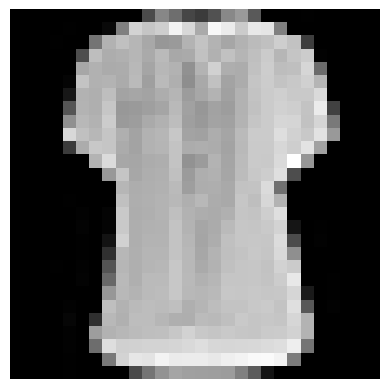

Shirt


In [843]:
plt.imshow(train_x[55].reshape(28,28),cmap='gray')
plt.axis('off')
plt.show()
print(class_names[train_y[55]])

In [844]:
model = models.Sequential([
    layers.Dense(128,activation='relu',input_shape=(784,)) ,
    layers.Dense(32,activation='relu'),
    layers.Dense(32,activation='relu'),
    layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [845]:
history = model.fit(train_x,train_y,epochs=40,batch_size=2500,validation_data=(val_x,val_y))

Epoch 1/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4551 - loss: 1.6590 - val_accuracy: 0.6553 - val_loss: 1.1260
Epoch 2/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7081 - loss: 0.8871 - val_accuracy: 0.7573 - val_loss: 0.7082
Epoch 3/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7775 - loss: 0.6415 - val_accuracy: 0.8022 - val_loss: 0.5824
Epoch 4/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8118 - loss: 0.5560 - val_accuracy: 0.8174 - val_loss: 0.5340
Epoch 5/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8257 - loss: 0.5095 - val_accuracy: 0.8290 - val_loss: 0.4983
Epoch 6/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8364 - loss: 0.4788 - val_accuracy: 0.8345 - val_loss: 0.4790
Epoch 7/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8431 - loss: 0.4544 - val_accuracy: 0.8440 - val_loss: 0.4540
Epoch 8/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8479 - loss: 0.4419 - val_accuracy: 0.8476 - val_loss:

In [846]:
def plot(history,name="") :
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.figure(figsize=(15,7))
    
    plt.subplot(1,2,1)
    plt.plot(epochs,loss,'r',label='Training loss')
    plt.plot(epochs,val_loss,'b',label='Validation loss')
    plt.title('Training and Validation Loss '+ name)
    plt.grid(True)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1,2,2)
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1 , len(accuracy) + 1)
    plt.plot(epochs,accuracy,'r',label='Training Accuracy')
    plt.plot(epochs,val_accuracy,'b',label='Validation Accuracy')
    plt.title('Training and Validation Accuracy ' + name)
    plt.grid(True)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
    print(f"min val_loss : {min(val_loss)}")
    print(f"max val_acc : {max(val_accuracy)}")
    print(f"Latest val_loss : {val_loss[len(val_loss)-1]}")
    print(f"Latest val_acc : {val_accuracy[len(val_accuracy)-1]}")

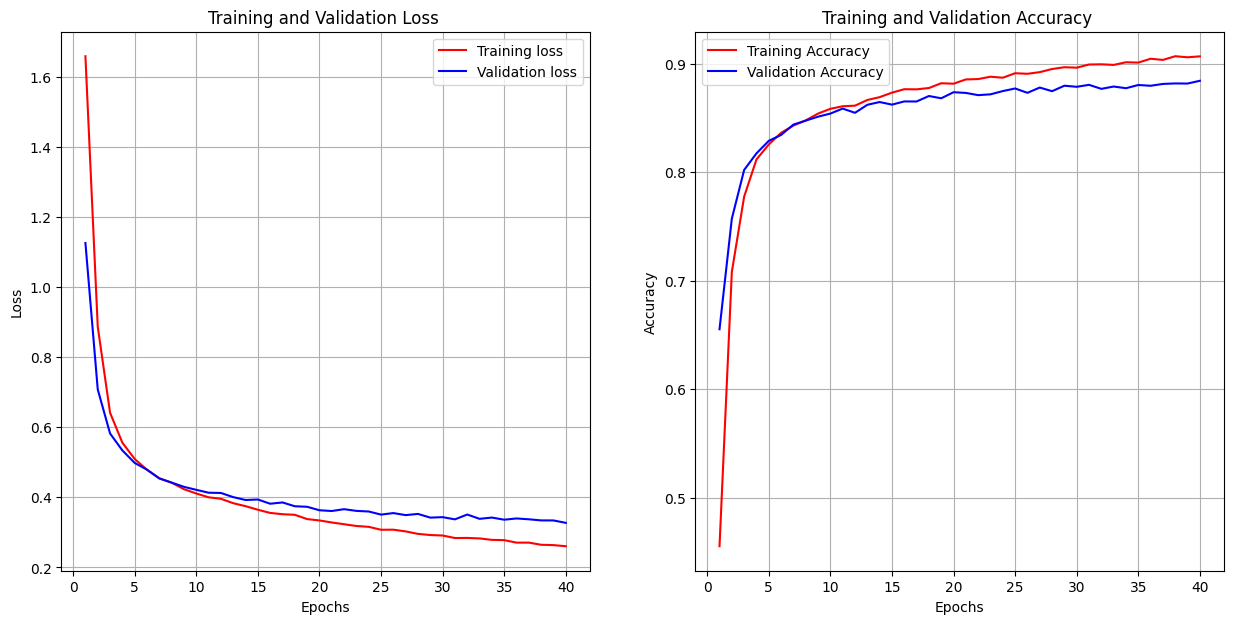

min val_loss : 0.3272908329963684
max val_acc : 0.8844000101089478
Latest val_loss : 0.3272908329963684
Latest val_acc : 0.8844000101089478
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 305us/step - accuracy: 0.8755 - loss: 0.3602
0.36015474796295166 0.8755000233650208


In [847]:
plot(history)
loss , acc = model.evaluate(test_x,test_y)
print(loss,acc)

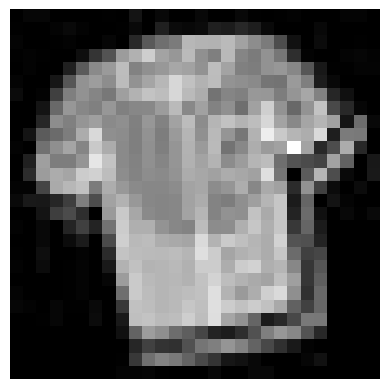

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predicted : Shirt
ความมั่นใจ: 63.76%


In [848]:
filename = f"Shirt.jpg"
img = load_img(filename,color_mode='grayscale',target_size=(28,28))

img_array = img_to_array(img)
img_array = 255.0 - img_array

img_array = img_array.reshape((1,28*28)).astype('float32')/255.0

plt.imshow(img_array.reshape(28,28) , cmap='gray')
plt.axis('off')
plt.show()

prediction = history.model.predict(img_array)
predicted_digit = np.argmax(prediction)

print(f"Predicted : {class_names[predicted_digit]}")
print(f"ความมั่นใจ: {prediction[0][predicted_digit] * 100:.2f}%")

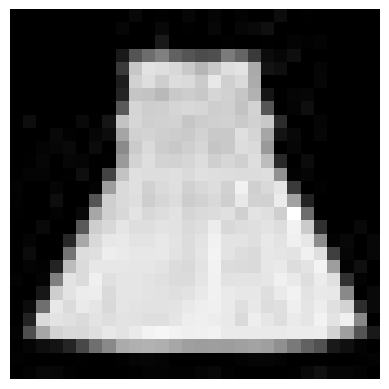

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Predicted : Bag
ความมั่นใจ: 47.59%


In [849]:
filename = f"Dress.jpg"
img = load_img(filename,color_mode='grayscale',target_size=(28,28))

img_array = img_to_array(img)
img_array = 255.0 - img_array

img_array = img_array.reshape((1,28*28)).astype('float32')/255.0

plt.imshow(img_array.reshape(28,28) , cmap='gray')
plt.axis('off')
plt.show()

prediction = history.model.predict(img_array)
predicted_digit = np.argmax(prediction)

print(f"Predicted : {class_names[predicted_digit]}")
print(f"ความมั่นใจ: {prediction[0][predicted_digit] * 100:.2f}%")

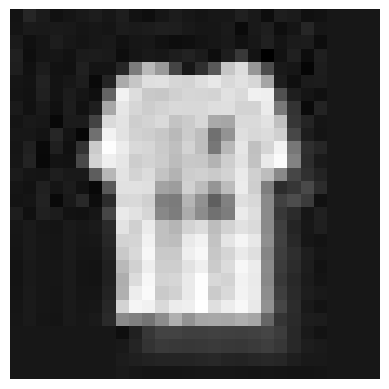

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Predicted : Bag
ความมั่นใจ: 54.27%


In [850]:
filename = f"T-shirt.jpg"
img = load_img(filename,color_mode='grayscale',target_size=(28,28))

img_array = img_to_array(img)
img_array = 255.0 - img_array

img_array = img_array.reshape((1,28*28)).astype('float32')/255.0

plt.imshow(img_array.reshape(28,28) , cmap='gray')
plt.axis('off')
plt.show()

prediction = history.model.predict(img_array)
predicted_digit = np.argmax(prediction)

print(f"Predicted : {class_names[predicted_digit]}")
print(f"ความมั่นใจ: {prediction[0][predicted_digit] * 100:.2f}%")